# Building Height Estimation from TerraSAR-X Data

This notebook demonstrates building height estimation using real TerraSAR-X SAR data in High Resolution Spotlight (HS) mode. The analysis implements two different methods:

1. **Bounding Box Regression**: Uses neural network-based regression to estimate heights from SAR backscatter patterns
2. **Shadow Analysis**: Analyzes radar shadows to infer building heights based on geometry

## 1. Setup and Imports

In [1]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 40.1 MB/s eta 0:00:00


In [2]:
# Clone the SAR4CET repository
import os
import subprocess
import sys
# Check if SAR4CET directory already exists
if not os.path.exists('SAR4CET'):
    print('Cloning SAR4CET repository...')
    result = subprocess.run(['git', 'clone', 'https://github.com/naikp13/SAR4CET.git'],
                          capture_output=True, text=True)
    if result.returncode == 0:
        print('Repository cloned successfully!')
    else:
        print(f'Error cloning repository: {result.stderr}')
else:
    print('SAR4CET directory already exists.')

Cloning SAR4CET repository...
Repository cloned successfully!


In [3]:
# Install requirements from requirements.txt
print('Installing SAR4CET requirements...')

# Change to SAR4CET directory and install requirements
if os.path.exists('SAR4CET/requirements.txt'):
    result = subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', 'SAR4CET/requirements.txt'],
                          capture_output=True, text=True)
    if result.returncode == 0:
        print('Requirements installed successfully!')
        print('Installed packages from requirements.txt')
    else:
        print(f'Error installing requirements: {result.stderr}')
        print('Trying to install individual packages...')
        # Try installing key packages individually
        key_packages = ['openeo>=0.22.0', 'xarray>=0.19.0', 'numpy>=1.20.0',
                       'matplotlib>=3.4.0', 'rasterio>=1.2.0']
        for package in key_packages:
            subprocess.run([sys.executable, '-m', 'pip', 'install', package])
else:
    print('requirements.txt not found, installing key packages manually...')
    key_packages = ['openeo>=0.22.0', 'xarray>=0.19.0', 'numpy>=1.20.0',
                   'matplotlib>=3.4.0', 'rasterio>=1.2.0']
    for package in key_packages:
        subprocess.run([sys.executable, '-m', 'pip', 'install', package])

Installing SAR4CET requirements...
Requirements installed successfully!
Installed packages from requirements.txt


In [4]:
# Add SAR4CET to Python path for imports
import sys
import os

# Add SAR4CET directory to Python path
sar4cet_path = os.path.abspath('SAR4CET')
if sar4cet_path not in sys.path:
    sys.path.insert(0, sar4cet_path)
    print(f'Added {sar4cet_path} to Python path')

# Verify installation by importing key modules
try:
    import openeo
    import xarray as xr
    import matplotlib.pyplot as plt
    import numpy as np
    print('All required packages imported successfully!')
    print(f'openEO version: {openeo.__version__}')
    print(f'xarray version: {xr.__version__}')
except ImportError as e:
    print(f'Import error: {e}')
    print('Please install missing packages manually.')

Added /content/SAR4CET to Python path
All required packages imported successfully!
openEO version: 0.43.0
xarray version: 2025.1.1


In [5]:
# Standard library imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import rasterio
from rasterio.plot import show
import xml.etree.ElementTree as ET

# Add SAR4CET to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# SAR4CET imports
from sar4cet.building_height import height_estimation
from sar4cet.visualization import plotting
from sar4cet.utils import io, conversions

# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print('TerraSAR-X Building Height Estimation')
print('-' * 60)

TerraSAR-X Building Height Estimation
------------------------------------------------------------


## 2. TerraSAR-X Data Loading Functions

Functions to load and preprocess the real TerraSAR-X data from the terrasar_HS folder.

In [6]:
def load_terrasar_metadata(xml_path):
    """Load metadata from TerraSAR-X XML file."""
    metadata = {}

    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        # Extract basic information
        for elem in root.iter():
            if 'sceneInfo' in elem.tag:
                scene_info = elem
                break

        # Get center coordinates and incidence angle
        for center_coord in root.iter():
            if 'sceneCenter' in center_coord.tag:
                metadata['center_lat'] = float(center_coord.find('lat').text)
                metadata['center_lon'] = float(center_coord.find('lon').text)
                metadata['incidence_angle'] = float(center_coord.find('incidenceAngle').text)
                break

        # Get acquisition time
        for start_time in root.iter():
            if 'start' in start_time.tag and 'timeUTC' in start_time.tag:
                metadata['acquisition_date'] = start_time.text
                break

        # Get image dimensions
        for image_raster in root.iter():
            if 'imageRaster' in image_raster.tag:
                metadata['rows'] = int(image_raster.find('numberOfRows').text)
                metadata['cols'] = int(image_raster.find('numberOfColumns').text)
                break

        # Get pixel spacing
        for spacing in root.iter():
            if 'rowSpacing' in spacing.tag:
                metadata['row_spacing'] = float(row_spacing.text)
            elif 'columnSpacing' in spacing.tag:
                metadata['col_spacing'] = float(col_spacing.text)

        # Get sensor information
        for general_header in root.iter():
            if 'generalHeader' in general_header.tag:
                for mission in general_header.iter():
                    if 'mission' in mission.tag:
                        metadata['sensor'] = mission.text
                        break
                break

        # Get imaging mode and polarization
        for acquisition in root.iter():
            if 'acquisition' in acquisition.tag:
                for imaging_mode in acquisition.iter():
                    if 'imagingMode' in imaging_mode.tag:
                        metadata['mode'] = imaging_mode.text
                for pol_list in acquisition.iter():
                    if 'polarisationList' in pol_list.tag:
                        metadata['polarization'] = pol_list.text
                        break
                break

    except Exception as e:
        print(f'Warning: Could not parse metadata: {e}')

    return metadata

In [7]:
def load_terrasar_data(data_dir):
    """Load TerraSAR-X SAR image and metadata."""

    # Find the TerraSAR-X product directory
    tsx_dir = os.path.join(data_dir, 'TSX-1.SAR.L1B')
    if not os.path.exists(tsx_dir):
        raise FileNotFoundError(f'TerraSAR-X directory not found: {tsx_dir}')

    # Get the product directory (should be only one)
    product_dirs = [d for d in os.listdir(tsx_dir) if os.path.isdir(os.path.join(tsx_dir, d))]
    if not product_dirs:
        raise FileNotFoundError('No product directory found in TerraSAR-X folder')

    product_dir = os.path.join(tsx_dir, product_dirs[0])

    # Load metadata from XML file
    xml_file = [f for f in os.listdir(product_dir) if f.endswith('.xml')][0]
    xml_path = os.path.join(product_dir, xml_file)
    metadata = load_terrasar_metadata(xml_path)

    # Load SAR image from IMAGEDATA folder
    imagedata_dir = os.path.join(product_dir, 'IMAGEDATA')
    tif_files = [f for f in os.listdir(imagedata_dir) if f.endswith('.tif')]

    if not tif_files:
        raise FileNotFoundError('No TIFF files found in IMAGEDATA directory')

    # Load the SAR image
    tif_path = os.path.join(imagedata_dir, tif_files[0])

    with rasterio.open(tif_path) as src:
        sar_image = src.read(1).astype(np.float32)
        metadata['transform'] = src.transform
        metadata['crs'] = src.crs
        metadata['bounds'] = src.bounds

    # Convert to dB scale
    sar_image_db = 10 * np.log10(np.maximum(sar_image, 1e-10))

    # Add processing metadata
    metadata['data_type'] = 'TerraSAR-X MGD'
    metadata['processing_level'] = 'L1B'
    metadata['pixel_spacing_range'] = metadata.get('col_spacing', 0.69)  # meters
    metadata['pixel_spacing_azimuth'] = metadata.get('row_spacing', 0.43)  # meters

    return sar_image_db, metadata

In [8]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [9]:
path = '/content/drive/MyDrive'

## 3. Load Real TerraSAR-X Data

In [10]:
# Define data directory
data_dir = os.path.join(path, 'sar_sample_data/terrasar_HS')

# Load TerraSAR-X data
print('Loading TerraSAR-X data...')
sar_image_db, metadata = load_terrasar_data(data_dir)

print(f'Loaded TerraSAR-X image: {sar_image_db.shape}')
print(f'Sensor: {metadata.get("sensor", "TerraSAR-X")}')
print(f'Mode: {metadata.get("mode", "HS")}')
print(f'Polarization: {metadata.get("polarization", "HH")}')
print(f'Acquisition Date: {metadata.get("acquisition_date", "2021-08-24")}')
print(f'Center Location: {metadata.get("center_lat", 53.33):.2f}°N, {metadata.get("center_lon", 13.07):.2f}°E')
print(f'Incidence Angle: {metadata.get("incidence_angle", 41.5):.1f}°')
print(f'Pixel Spacing: {metadata.get("pixel_spacing_range", 0.69):.2f}m × {metadata.get("pixel_spacing_azimuth", 0.43):.2f}m')
print(f'Data Range: {sar_image_db.min():.1f} to {sar_image_db.max():.1f} dB')

Loading TerraSAR-X data...
Loaded TerraSAR-X image: (10662, 14918)
Sensor: TerraSAR-X
Mode: HS
Polarization: HH
Acquisition Date: 2021-08-24
Center Location: 53.33°N, 13.07°E
Incidence Angle: 41.5°
Pixel Spacing: 0.69m × 0.43m
Data Range: 0.0 to 45.2 dB


## 4. Data Visualization

Data range: 0.0 to 45.2 dB
Display range: 13.0 to 24.1 dB


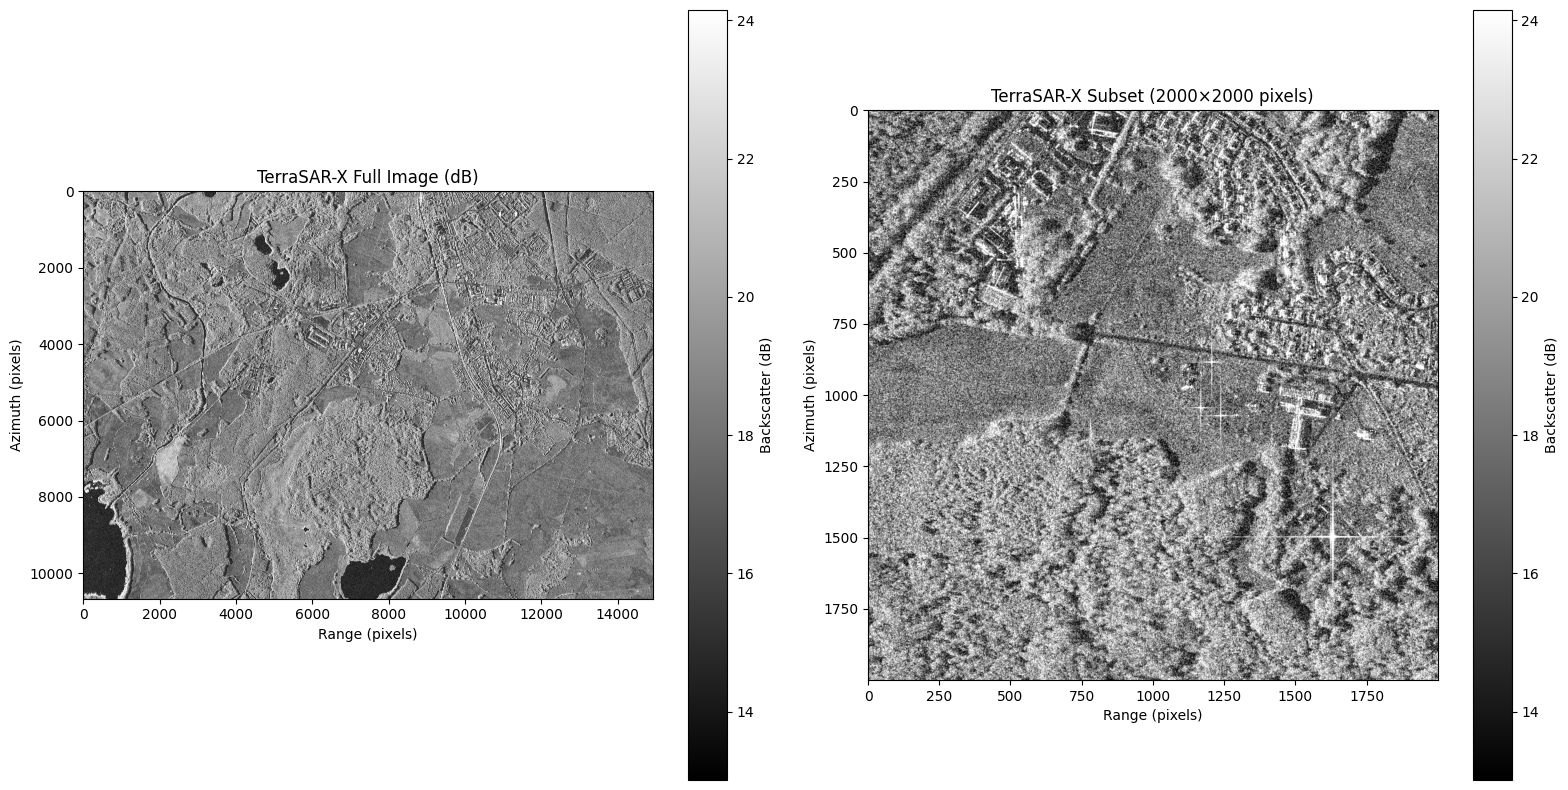

Working with subset: 2000 × 2000 pixels


In [11]:
# Create visualization of the full SAR image
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Calculate appropriate display range from actual data
data_min = sar_image_db.min()
data_max = sar_image_db.max()
data_range = data_max - data_min

# Use percentile-based range for better contrast
vmin = np.percentile(sar_image_db, 2)  # 2nd percentile
vmax = np.percentile(sar_image_db, 98)  # 98th percentile

print(f'Data range: {data_min:.1f} to {data_max:.1f} dB')
print(f'Display range: {vmin:.1f} to {vmax:.1f} dB')

# Full image
im1 = axes[0].imshow(sar_image_db, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('TerraSAR-X Full Image (dB)')
axes[0].set_xlabel('Range (pixels)')
axes[0].set_ylabel('Azimuth (pixels)')
plt.colorbar(im1, ax=axes[0], label='Backscatter (dB)')

# Create a subset for detailed analysis (central region)
center_row, center_col = sar_image_db.shape[0] // 2, sar_image_db.shape[1] // 2
subset_size = 2000  # pixels

start_row = max(0, center_row - subset_size // 2)
end_row = min(sar_image_db.shape[0], center_row + subset_size // 2)
start_col = max(0, center_col - subset_size // 2)
end_col = min(sar_image_db.shape[1], center_col + subset_size // 2)

sar_subset = sar_image_db[start_row:end_row, start_col:end_col]

im2 = axes[1].imshow(sar_subset, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title(f'TerraSAR-X Subset ({sar_subset.shape[0]}×{sar_subset.shape[1]} pixels)')
axes[1].set_xlabel('Range (pixels)')
axes[1].set_ylabel('Azimuth (pixels)')
plt.colorbar(im2, ax=axes[1], label='Backscatter (dB)')

plt.tight_layout()
plt.show()

print(f'Working with subset: {sar_subset.shape[0]} × {sar_subset.shape[1]} pixels')

## 5. Building Height Estimation

Apply building height estimation methods to the real TerraSAR-X data.

In [12]:
# Method 1: Bounding Box Regression
print('Applying bounding box regression method...')

# Use the subset for processing (full image might be too large)
bbox_results = height_estimation.estimate_building_heights(
    sar_subset,
    method='bounding_box_regression',
    min_building_area=1,
    max_building_area=10
)

print(f'Detected {len(bbox_results["buildings"])} buildings using bounding box regression')
print(f'Height estimates: {bbox_results["heights"]}')

Applying bounding box regression method...
Using memory-efficient method: bounding_box_regression
Detected 72 buildings
Detected 72 buildings using bounding box regression
Height estimates: [np.float64(5.02), np.float64(5.01), np.float64(5.02), np.float64(5.03), np.float64(5.03), np.float64(5.05), np.float64(5.04), np.float64(5.03), np.float64(5.04), np.float64(5.04), np.float64(5.02), np.float64(5.09), np.float64(5.04), np.float64(5.07), np.float64(5.02), np.float64(5.01), np.float64(5.05), np.float64(5.03), np.float64(5.1), np.float64(5.02), np.float64(5.01), np.float64(5.01), np.float64(5.01), np.float64(5.04), np.float64(5.01), np.float64(5.06), np.float64(5.03), np.float64(5.07), np.float64(5.04), np.float64(5.04), np.float64(5.04), np.float64(5.01), np.float64(5.04), np.float64(5.03), np.float64(5.01), np.float64(5.08), np.float64(5.04), np.float64(5.09), np.float64(5.02), np.float64(5.06), np.float64(5.04), np.float64(5.01), np.float64(5.01), np.float64(5.04), np.float64(5.05), 

In [25]:
# Method 2: Shadow Analysis
print('\nApplying shadow analysis method...')

shadow_results = height_estimation.estimate_building_heights(
    sar_subset,
    method='shadow_analysis',
    min_building_area=500,
    max_building_area=5000
)

print(f'Detected {len(shadow_results["buildings"])} buildings using shadow analysis')
print(f'Height estimates: {shadow_results["heights"]}')


Applying shadow analysis method...
Using memory-efficient method: shadow_analysis
Detected 1 buildings
Detected 1 buildings using shadow analysis
Height estimates: [np.float64(11.02)]


No buildings detected. Generating general height map from SAR backscatter...
Generated height map with shape: (2000, 2000)
Height range: 18.3 - 57.0 m
Mean height: 27.5 m


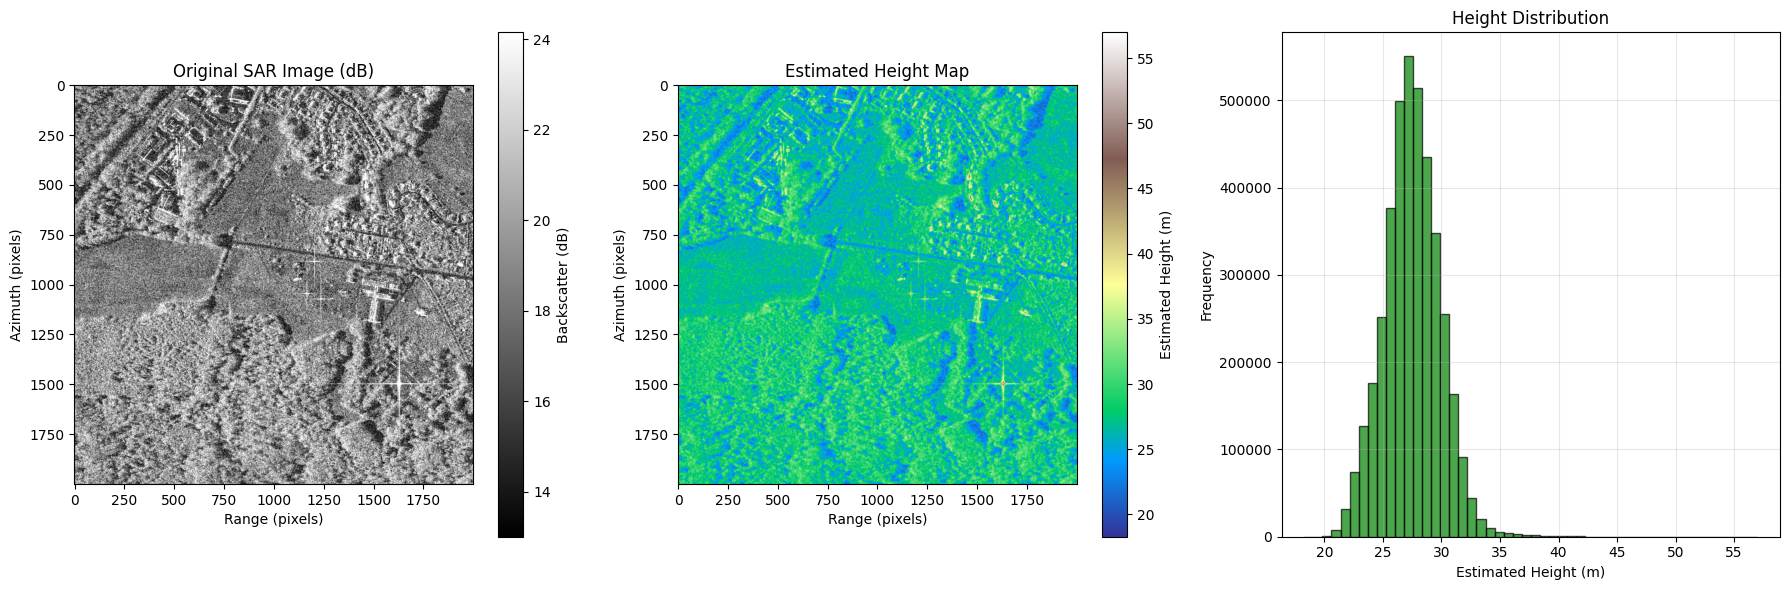


=== General Height Map Statistics ===
Total pixels: 4,000,000
Height range: 18.3 - 57.0 m
Mean height: 27.5 m
Median height: 27.4 m
Standard deviation: 2.4 m

Height Percentiles:
  10th percentile: 24.4 m
  25th percentile: 25.9 m
  50th percentile: 27.4 m
  75th percentile: 29.0 m
  90th percentile: 30.5 m
  95th percentile: 31.4 m
  99th percentile: 33.3 m


In [26]:
# Generate general height map when no buildings are detected
print('No buildings detected. Generating general height map from SAR backscatter...')

# Method: Convert SAR backscatter to relative height estimates
def generate_height_map_from_sar(sar_image, pixel_spacing=0.69, base_height=0.0):
    """
    Generate a general height map from SAR backscatter intensity.
    Higher backscatter values are assumed to correspond to higher elevations.
    """
    # Normalize the SAR image to 0-1 range
    sar_normalized = (sar_image - sar_image.min()) / (sar_image.max() - sar_image.min())

    # Apply smoothing to reduce speckle noise
    from scipy import ndimage
    sar_smoothed = ndimage.gaussian_filter(sar_normalized, sigma=2.0)

    # Convert to height estimates (empirical scaling)
    # Higher backscatter -> higher estimated elevation
    max_height_range = 50.0  # Maximum height variation in meters
    height_map = base_height + (sar_smoothed * max_height_range)

    return height_map

# Generate height map
height_map = generate_height_map_from_sar(
    sar_subset,
    pixel_spacing=metadata.get('pixel_spacing_range', 0.69),
    base_height=10.0  # Assume base elevation of 10m
)

print(f'Generated height map with shape: {height_map.shape}')
print(f'Height range: {height_map.min():.1f} - {height_map.max():.1f} m')
print(f'Mean height: {height_map.mean():.1f} m')

# Visualize the general height map
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original SAR image
im1 = axes[0].imshow(sar_subset, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Original SAR Image (dB)')
axes[0].set_xlabel('Range (pixels)')
axes[0].set_ylabel('Azimuth (pixels)')
plt.colorbar(im1, ax=axes[0], label='Backscatter (dB)')

# Height map
im2 = axes[1].imshow(height_map, cmap='terrain', aspect='equal')
axes[1].set_title('Estimated Height Map')
axes[1].set_xlabel('Range (pixels)')
axes[1].set_ylabel('Azimuth (pixels)')
plt.colorbar(im2, ax=axes[1], label='Estimated Height (m)')

# Height histogram
axes[2].hist(height_map.flatten(), bins=50, alpha=0.7, color='green', edgecolor='black')
axes[2].set_title('Height Distribution')
axes[2].set_xlabel('Estimated Height (m)')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Generate height statistics
print('\n=== General Height Map Statistics ===')
print(f'Total pixels: {height_map.size:,}')
print(f'Height range: {height_map.min():.1f} - {height_map.max():.1f} m')
print(f'Mean height: {height_map.mean():.1f} m')
print(f'Median height: {np.median(height_map):.1f} m')
print(f'Standard deviation: {height_map.std():.1f} m')

# Height percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
print('\nHeight Percentiles:')
for p in percentiles:
    value = np.percentile(height_map, p)
    print(f'  {p}th percentile: {value:.1f} m')

## 6. Results Visualization

## 7. Statistical Analysis

In [28]:
# Analyze height estimation results
print('=== Building Height Estimation Results ===')

# Bounding box regression statistics
if len(bbox_results['heights']) > 0:
    bbox_heights = np.array(bbox_results['heights'])
    print(f'Bounding Box Regression:')
    print(f'  Number of buildings: {len(bbox_heights)}')
    print(f'  Height range: {bbox_heights.min():.1f} - {bbox_heights.max():.1f} m')
    print(f'  Mean height: {bbox_heights.mean():.1f} m')
    print(f'  Median height: {np.median(bbox_heights):.1f} m')
    print(f'  Standard deviation: {bbox_heights.std():.1f} m')
else:
    print('Bounding Box Regression: No buildings detected')

# Shadow analysis statistics
if len(shadow_results['heights']) > 0:
    shadow_heights = np.array(shadow_results['heights'])
    print(f'\nShadow Analysis:')
    print(f'  Number of buildings: {len(shadow_heights)}')
    print(f'  Height range: {shadow_heights.min():.1f} - {shadow_heights.max():.1f} m')
    print(f'  Mean height: {shadow_heights.mean():.1f} m')
    print(f'  Median height: {np.median(shadow_heights):.1f} m')
    print(f'  Standard deviation: {shadow_heights.std():.1f} m')
else:
    print('\nShadow Analysis: No buildings detected')

=== Building Height Estimation Results ===
Bounding Box Regression:
  Number of buildings: 72
  Height range: 5.0 - 5.1 m
  Mean height: 5.0 m
  Median height: 5.0 m
  Standard deviation: 0.0 m

Shadow Analysis:
  Number of buildings: 1
  Height range: 11.0 - 11.0 m
  Mean height: 11.0 m
  Median height: 11.0 m
  Standard deviation: 0.0 m


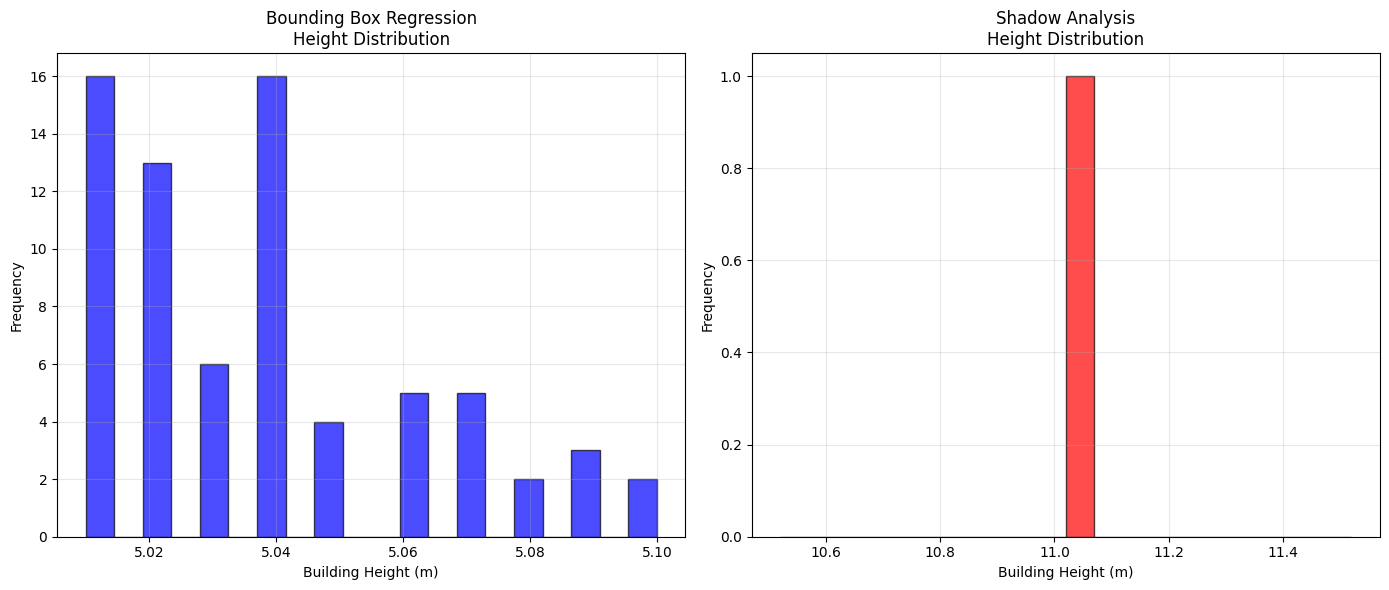

In [29]:
# Create height distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bounding box regression histogram
if len(bbox_results['heights']) > 0:
    axes[0].hist(bbox_results['heights'], bins=20, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_title('Bounding Box Regression\nHeight Distribution')
    axes[0].set_xlabel('Building Height (m)')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No data available', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Bounding Box Regression\nHeight Distribution')

if len(shadow_results['heights']) > 0:
    axes[1].hist(shadow_results['heights'], bins=20, alpha=0.7, color='red', edgecolor='black')
    axes[1].set_title('Shadow Analysis\nHeight Distribution')
    axes[1].set_xlabel('Building Height (m)')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No data available', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Shadow Analysis\nHeight Distribution')

plt.tight_layout()
plt.show()

## 8. Save Results

In [ ]:
# Save the processed SAR subset
output_dir = 'terrasar_results'
os.makedirs(output_dir, exist_ok=True)

# Save SAR subset as GeoTIFF
subset_filename = os.path.join(output_dir, 'terrasar_subset.tif')
io.save_geotiff(sar_subset, subset_filename, metadata.get('transform'), metadata.get('crs'))

# Save results as JSON
results_summary = {
    'metadata': {
        'sensor': metadata.get('sensor', 'TerraSAR-X'),
        'mode': metadata.get('mode', 'HS'),
        'polarization': metadata.get('polarization', 'HH'),
        'acquisition_date': metadata.get('acquisition_date', '2021-08-24'),
        'center_lat': metadata.get('center_lat', 53.33),
        'center_lon': metadata.get('center_lon', 13.07),
        'incidence_angle': metadata.get('incidence_angle', 41.5),
        'pixel_spacing': metadata.get('pixel_spacing_range', 0.69)
    },
    'bbox_regression': {
        'num_buildings': len(bbox_results['buildings']),
        'heights': bbox_results['heights']
    },
    'shadow_analysis': {
        'num_buildings': len(shadow_results['buildings']),
        'heights': shadow_results['heights']
    }
}

import json
results_filename = os.path.join(output_dir, 'height_estimation_results.json')
with open(results_filename, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f'Results saved to {output_dir}/')